### 06 - SVM (SVR with RBF kernel)

SVR to predict demand_log. Train 2022-2024, test 2025.
SVR is O(n^2) so a 10K subsample is used for both gridsearch and final fit.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/06_svm', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

FEATURES = ['T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend']

df = df.dropna(subset=FEATURES)
print(f'Shape after dropping NAs: {df.shape}')

Shape after dropping NAs: (35008, 19)


#### 1. Train / Test Split and Scaling

In [ ]:
train = df[df.index.year < 2025]
test  = df[df.index.year == 2025]

X_train_raw = train[FEATURES].values
y_train     = train['demand_log'].values
X_test_raw  = test[FEATURES].values
y_test      = test['demand_log'].values

# fit scaler on train only
scaler      = StandardScaler()
X_train     = scaler.fit_transform(X_train_raw)
X_test      = scaler.transform(X_test_raw)

# 10K subsample - full 26K is too slow for RBF kernel
rng  = np.random.default_rng(42)
idx  = rng.choice(len(X_train), size=10_000, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]

print(f'Train: {len(X_train):,}  |  Subsample: {len(X_sub):,}  |  Test: {len(X_test):,}')

Train: 26,260  |  Subsample: 10,000  |  Test: 8,748


#### 2. Grid Search

In [3]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1]
}

gs = GridSearchCV(
    SVR(kernel='rbf'), param_grid,
    cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
gs.fit(X_sub, y_sub)

best_C, best_gamma = gs.best_params_['C'], gs.best_params_['gamma']
print(f'Best params: C={best_C}, gamma={best_gamma}')
print(f'Best CV RMSE (log scale): {np.sqrt(-gs.best_score_):.4f}')

Best params: C=100, gamma=0.01
Best CV RMSE (log scale): 0.0609


In [4]:
# grid search results
results = pd.DataFrame(gs.cv_results_)
pivot = results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
).apply(lambda x: np.sqrt(-x)).round(4)
print('CV RMSE by C / gamma:')
print(pivot)

CV RMSE by C / gamma:
param_gamma    0.01     0.1   scale
param_C                            
0.1          0.0777  0.0646  0.0646
1.0          0.0649  0.0616  0.0615
10.0         0.0628  0.0633  0.0629
100.0        0.0609  0.0692  0.0691


#### 3. Final Model

In [5]:
svr = SVR(kernel='rbf', C=best_C, gamma=best_gamma)
svr.fit(X_sub, y_sub)   # trained on the same 10K subsample
print('Model fitted.')
print(f'Support vectors: {svr.n_support_[0]:,}')

Model fitted.
Support vectors: 621


#### 4. Test Set Predictions

In [6]:
y_pred_log = svr.predict(X_test)
y_pred     = np.exp(y_pred_log)
y_actual   = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)

print(f'RMSE : {rmse:,.1f} kW  ({rmse / y_actual.mean() * 100:.1f}% of mean)')
print(f'MAE  : {mae:,.1f} kW  ({mae  / y_actual.mean() * 100:.1f}% of mean)')

RMSE : 4,768.8 kW  (6.4% of mean)
MAE  : 3,481.3 kW  (4.7% of mean)


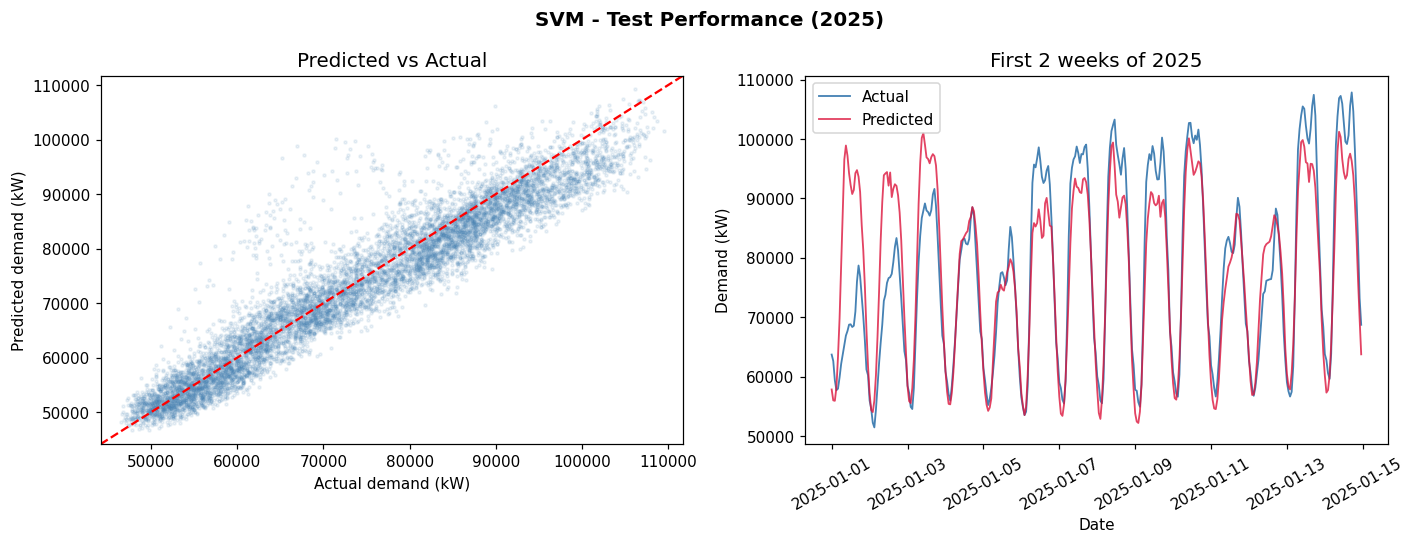

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter
lim = [y_actual.min() * 0.95, y_actual.max() * 1.02]
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual demand (kW)')
axes[0].set_ylabel('Predicted demand (kW)')
axes[0].set_title('Predicted vs Actual')

# first 2 weeks of 2025 — same window as LM and GAM
two_weeks  = test.iloc[:24*14]
X_tw       = scaler.transform(two_weeks[FEATURES].values)
y_tw_pred  = np.exp(svr.predict(X_tw))
y_tw_actual = np.exp(two_weeks['demand_log'].values)

axes[1].plot(two_weeks.index, y_tw_actual, lw=1.2, label='Actual',    color='steelblue')
axes[1].plot(two_weeks.index, y_tw_pred,   lw=1.2, label='Predicted', color='crimson', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kW)')
axes[1].set_title('First 2 weeks of 2025')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('SVM - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/06_svm/06_16_svm_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### 5. Save Metrics

In [8]:
new_row = pd.DataFrame([{
    'model':    'SVM',
    'rmse':     round(rmse, 1),
    'mae':      round(mae, 1),
    'r2_train': np.nan,
    'auc':      np.nan
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'SVM']
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row.to_string())

          model      rmse       mae  r2_train     auc
0            LM  7623.700  6125.800    0.7855     NaN
1   GLM_Poisson     2.575     1.441    0.6887     NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593
3           GAM  7199.800  5829.100    0.8081     NaN
4           SVM  4768.800  3481.300       NaN     NaN
